In [92]:
import awkward as ak
import numpy as np

import matplotlib.pyplot as plt
import mplhep as hep

import hist
from hist import Hist

from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
from topcoffea.modules.histEFT import HistEFT
NanoAODSchema.warn_missing_crossrefs = False

from coffea.analysis_tools import PackedSelection
from topcoffea.modules import utils
import topcoffea.modules.eft_helper as efth

from ttbarEFT.modules.paths import ttbarEFT_path


import re
import pickle, gzip

import os
import cloudpickle

from scipy.optimize import curve_fit
from scipy.stats import chisquare, goodness_of_fit

In [136]:
Powheg = pickle.load(gzip.open("Powheg_avgpt_smallerbins_var2.pkl.gz"))['ttbar']['avg_toppt']
SMEFTsim = pickle.load(gzip.open("SMEFTsim_avgpt_smallerbins_var2.pkl.gz"))['ttbar']['avg_toppt']

# Powheg = pickle.load(gzip.open("Powheg_avgpt_smallerbins_var.pkl.gz"))['ttbar']['avg_toppt']
# SMEFTsim = pickle.load(gzip.open("SMEFTsim_avgpt_smallerbins_var.pkl.gz"))['ttbar']['avg_toppt']

In [105]:
current_reweight = pickle.load(gzip.open(ttbarEFT_path(f'data/LOtoNLO/ttbarLO_SF.pkl.gz')))['ttbarLO_SF']
current_reweight

Hist(Variable(array([   0.,   10.,   20.,   30.,   40.,   50.,   60.,   70.,   80.,
         90.,  100.,  110.,  120.,  130.,  140.,  150.,  160.,  170.,
        180.,  190.,  200.,  210.,  220.,  230.,  240.,  250.,  260.,
        270.,  280.,  290.,  300.,  320.,  340.,  360.,  380.,  400.,
        450.,  500.,  550.,  600.,  650.,  750.,  850., 1000., 1500.]), name='avg_toppt', label='average $p_T$ of the top quarks [GeV]'), storage=Weight()) # Sum: WeightedSum(value=40.8455, variance=0)

(0.3, 1.2)

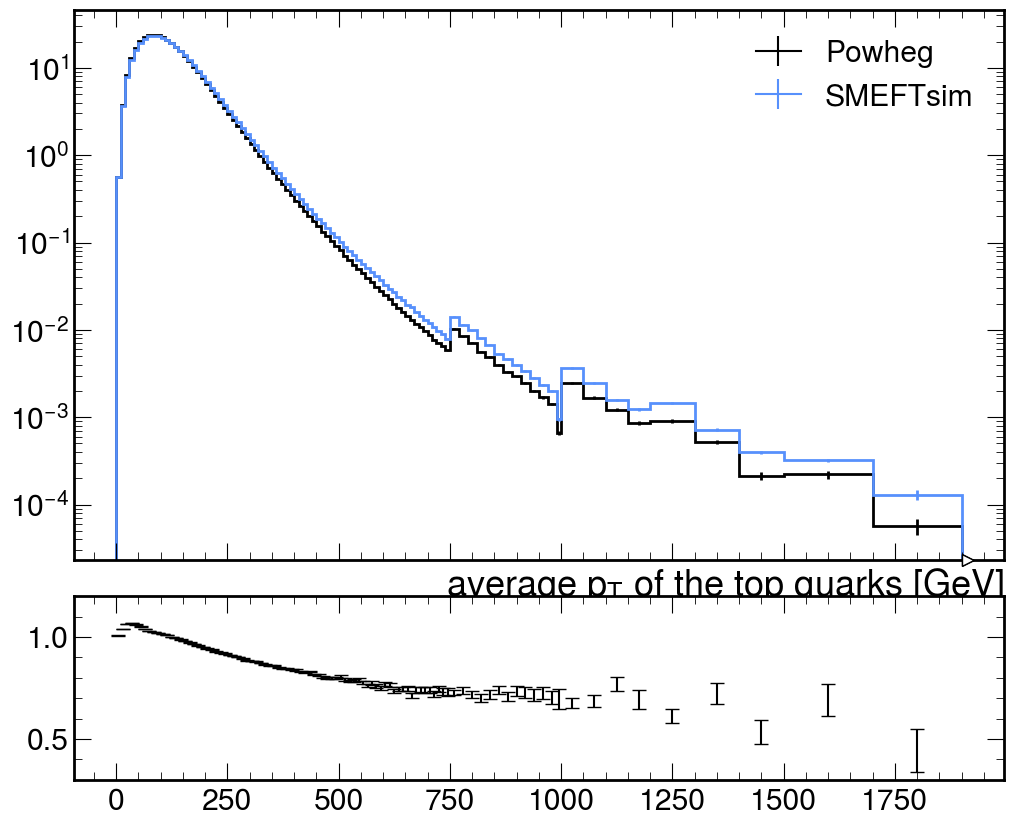

In [137]:
hep.style.use('CMS')
fig, (ax, rax) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12,10),
    gridspec_kw={'height_ratios': (3, 1)},
    sharex=True
)
fig.subplots_adjust(hspace=.1)

yvals_num = Powheg.values()
yvals_denom = SMEFTsim.values()
ratio = yvals_num/yvals_denom
centers = SMEFTsim.axes.centers[0]
sigma_num = np.sqrt(Powheg.variances())
sigma_denom = np.sqrt(SMEFTsim.variances())
sigma_y = np.multiply(np.abs(ratio), np.sqrt(np.add(np.square(np.divide(sigma_num, yvals_num)), np.square(np.divide(sigma_denom, yvals_denom)))))

# rax.scatter(centers, ratio, label="new")
rax.errorbar(centers, ratio, xerr = None, yerr = sigma_y, capsize=5, ls='none', color='black')

hep.histplot(Powheg, ax=ax, stack=False, yerr=True, linewidth=2, label='Powheg', color='black')
hep.histplot(SMEFTsim, ax=ax, stack=False, yerr=True, linewidth=2, label='SMEFTsim')

ax.legend()
ax.set_yscale('log')
# ax.set_xlim([800, 2000])
rax.set_ylim([0.3, 1.2])

/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/mplhep/error_estimation.py:49: RuntimeWarning: divide by zero encountered in divide
  counts = sumw / scale


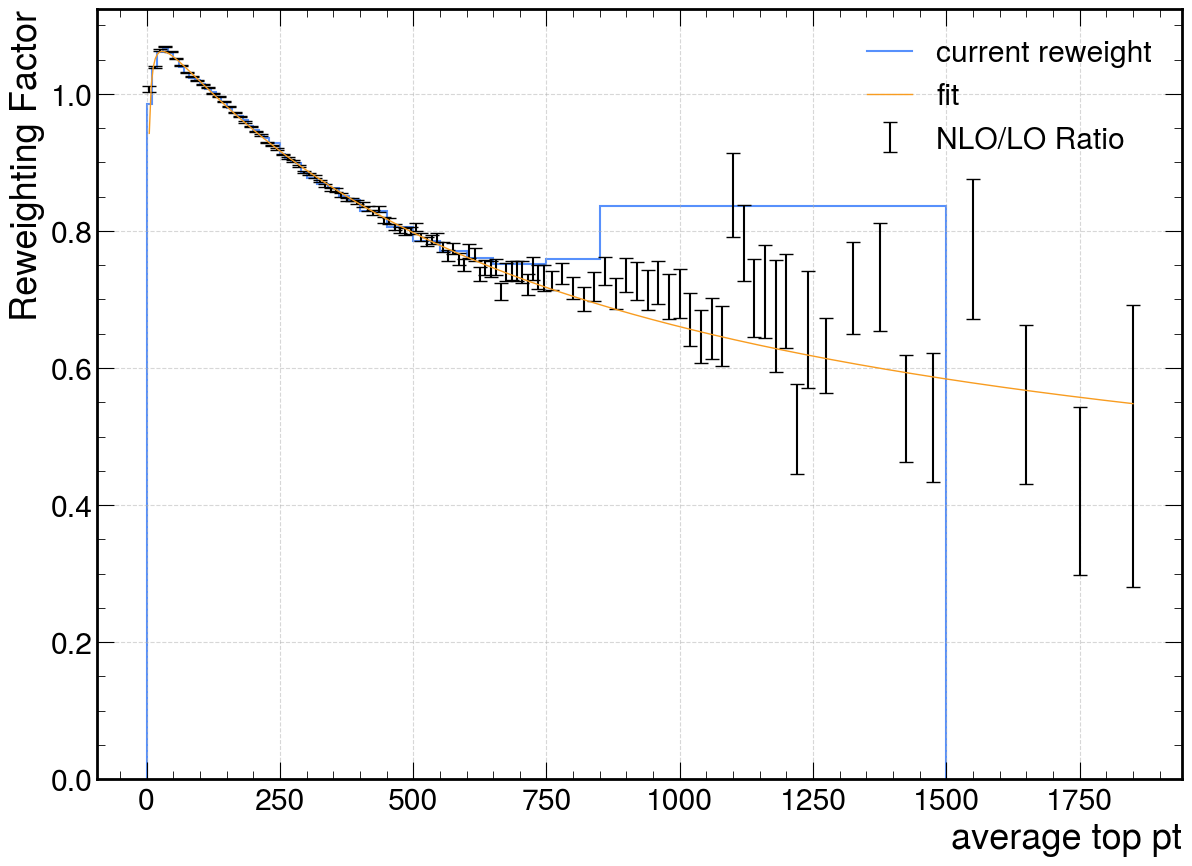

In [123]:
def pade22(x, p0, p1, p2, p3, p4):
    return (p0 + p1*x + p2*x**2) / (1 + p3*x + p4*x**2)

pade22_popt0, pade22_pcov0 = curve_fit(pade_22, centers[1:], ratio[1:], 
                       sigma=sigma_y[1:], p0=[1.0, 0.01, 0.0001, 0.01, 0.0001])

xfine = np.linspace(centers.min(), centers.max(), 500)
y_fit = pade22(xfine, *pade22_popt0)

hep.style.use('CMS')
fig, ax = plt.subplots(
    figsize=(14,10)
)

ax.errorbar(centers, ratio, xerr = None, yerr = sigma_y, capsize=5, ls='none', color='black', label='NLO/LO Ratio')
hep.histplot(current_reweight, label='current reweight', yerr=False)

# ax.plot(xfine, y_exp_poly, linewidth=2, label='exp')
# ax.plot(xfine, y_log_poly, linewidth=1, label='log poly')
# ax.plot(xfine, y_pade, linewidth=1, label='pade')
ax.plot(xfine, y_fit, linewidth=1, label='fit')
# ax.plot(xfine, y_pade33, linewidth=1, label='pade33')
# ax.plot(xfine, y_exp_poly, linewidth=1, label='exp_poly')


ax.set_ylabel("Reweighting Factor")
ax.set_xlabel("average top pt")
ax.grid(True, linestyle='--', alpha=0.5)
# ax.set_xlim([0, 500])
ax.legend()

In [121]:
print(pade22_popt0)

[-2.16361313e+04  2.77994157e+04  1.05253571e+01  2.47965162e+04
  3.32168257e+01]


In [138]:
def pade(x, A, B, C):
    return (A + B*x) / (1 + C*x)

def pade22(x, p0, p1, p2, p3, p4):
    return (p0 + p1*x + p2*x**2) / (1 + p3*x + p4*x**2)

def pade33(x, p0, p1, p2, p3, p4, p5, p6):
    return (p0 + p1*x + p2*x**2 + p5*x**3) / (1 + p3*x + p4*x**2 + p6*x**3)

def log_poly(x, a, b, c):
    l = np.log(x)
    return a + b*l + c*l**2

def exp_poly(x, A, B, C):
    return np.exp(A + B*x + C*x**2)

In [139]:
exp_poly_popt, exp_poly_pcov = curve_fit(exp_poly, centers[4:], ratio[4:], 
                       sigma=sigma_y[4:], p0=[0.1, -0.001, -0.000001])

log_poly_popt, log_poly_pcov = curve_fit(log_poly, centers, ratio, 
                       sigma=sigma_y, p0=[1, -0.1, -0.01])
# log_poly_popt, log_poly_pcov = curve_fit(log_poly, centers[3:], ratio[3:], 
#                        sigma=sigma_y[3:], p0=[1, -0.1, -0.01])

# p0=1 (intercept), p4 and p2 should be small and similar for a plateau
# p0_guess = [1.0, 0.01, 0.0001, 0.01, 0.0001]
pade_popt, pade_pcov = curve_fit(pade, centers, ratio, 
                       sigma=sigma_y, p0=[1.0, 0.01, 0.01])

pade22_popt, pade22_pcov = curve_fit(pade_22, centers[5:], ratio[5:], 
                       sigma=sigma_y[5:], p0=[1.0, 0.01, 0.0001, 0.01, 0.0001])
pade22_popt0, pade22_pcov0 = curve_fit(pade_22, centers, ratio, 
                       sigma=sigma_y, p0=[1.0, 0.01, 0.0001, 0.01, 0.0001])

pade33_popt, pade33_pcov = curve_fit(pade33, centers, ratio, 
                       sigma=sigma_y, p0=[1.0, 0.01, 0.0001, 0.01, 0.0001, 0.0001, 0.00001])

In [140]:
xfine = np.linspace(centers.min(), centers.max(), 500)
y_pade = pade(xfine, *pade_popt)
y_exp_poly = exp_poly(xfine, *exp_poly_popt)
y_log_poly = log_poly(xfine, *log_poly_popt)
y_pade22 = pade22(xfine, *pade22_popt)
y_pade220 = pade22(xfine, *pade22_popt0)
y_pade33 = pade33(xfine, *pade33_popt)
y_exp_poly = exp_poly(xfine, *exp_poly_popt)

# y_log_poly0 = log_poly(x_fine, *log0_poly_popt)

In [142]:
print(pade22_popt) # trying pade22_popt 
print(pade22_popt0)
print(pade33_popt)

[1.07967616e+00 5.20771350e-04 2.63260682e-06 9.68647048e-04
 4.11285113e-06]
[8.40285547e-01 3.08866386e-01 1.17619324e-04 2.76065086e-01
 3.70323091e-04]
[ 7.10764397e-01  5.98339663e-01 -8.95987599e-05  5.38719462e-01
  3.74155721e-04  2.73932301e-07  2.22105423e-07]


In [98]:
# residuals = y_data - y_pred
# ss_res = np.sum(residuals**2)

# # Total Sum of Squares (SS_tot)
# ss_tot = np.sum((y_data - np.mean(y_data))**2)

# # Calculate R-squared
# r_squared = 1 - (ss_res / ss_tot)

print(np.sum(exp_poly_pcov**2))
print(np.sum(log_poly_pcov**2))
print(np.sum(pade22_pcov**2))
print(np.sum(pade22_pcov0**2))
print(np.sum(pade33_pcov**2))

8.006028762847227e-13
5.624178254440399e-08
2.1216023821811276e-10
0.0029903791366554847
0.6560138521410557


/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/mplhep/error_estimation.py:49: RuntimeWarning: divide by zero encountered in divide
  counts = sumw / scale


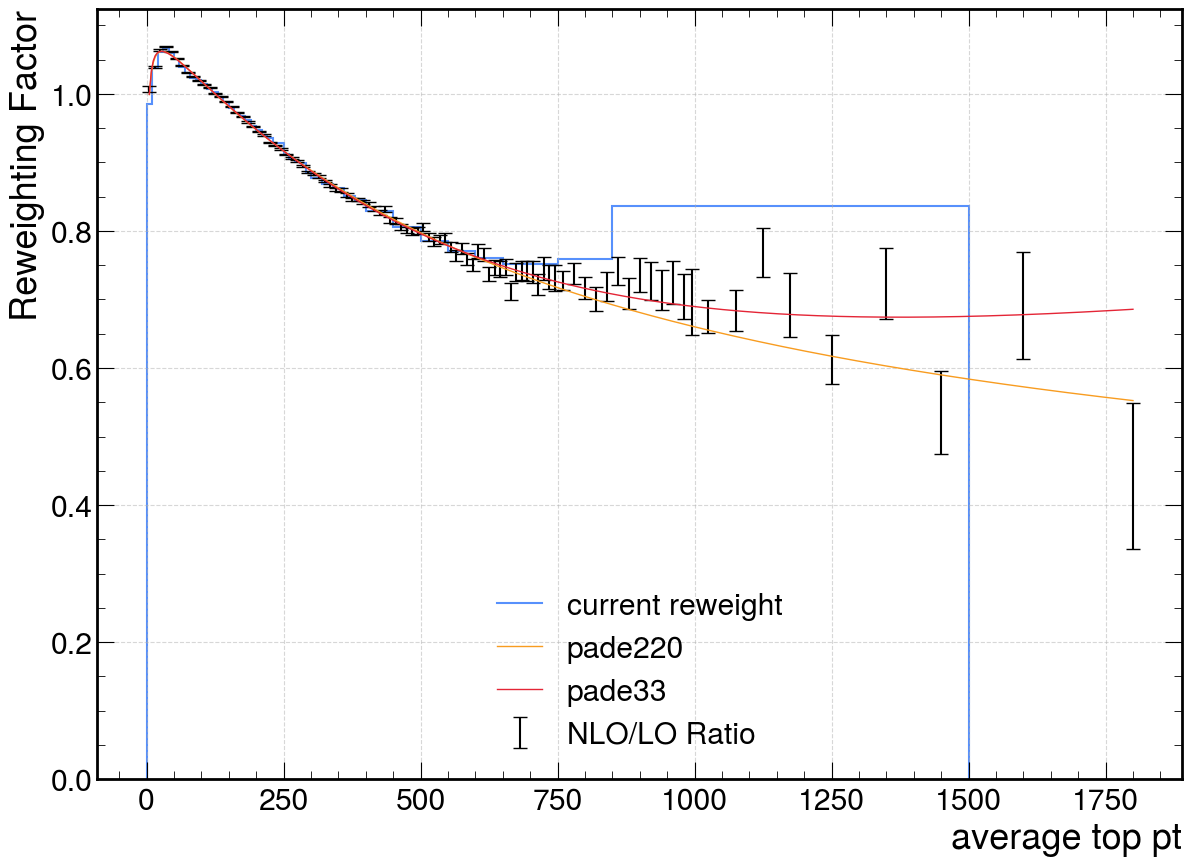

In [141]:
hep.style.use('CMS')
fig, ax = plt.subplots(
    figsize=(14,10)
)

ax.errorbar(centers, ratio, xerr = None, yerr = sigma_y, capsize=5, ls='none', color='black', label='NLO/LO Ratio')

hep.histplot(current_reweight, label='current reweight', yerr=False)

# ax.plot(xfine, y_exp_poly, linewidth=2, label='exp')
# ax.plot(xfine, y_log_poly, linewidth=1, label='log poly')
# ax.plot(xfine, y_pade, linewidth=1, label='pade')
# ax.plot(xfine, y_pade22, linewidth=1, label='pade22')
ax.plot(xfine, y_pade220, linewidth=1, label='pade220')
ax.plot(xfine, y_pade33, linewidth=1, label='pade33')
# ax.plot(xfine, y_exp_poly, linewidth=1, label='exp_poly')


ax.set_ylabel("Reweighting Factor")
ax.set_xlabel("average top pt")
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()



In [68]:
from supersmoother import SuperSmoother, LinearSmoother

In [83]:
model = SuperSmoother(alpha=1)
model.span_int(0.8)
model.fit(centers, ratio, sigma_y)
# model.span(centers)

AttributeError: 'SuperSmoother' object has no attribute 'span'

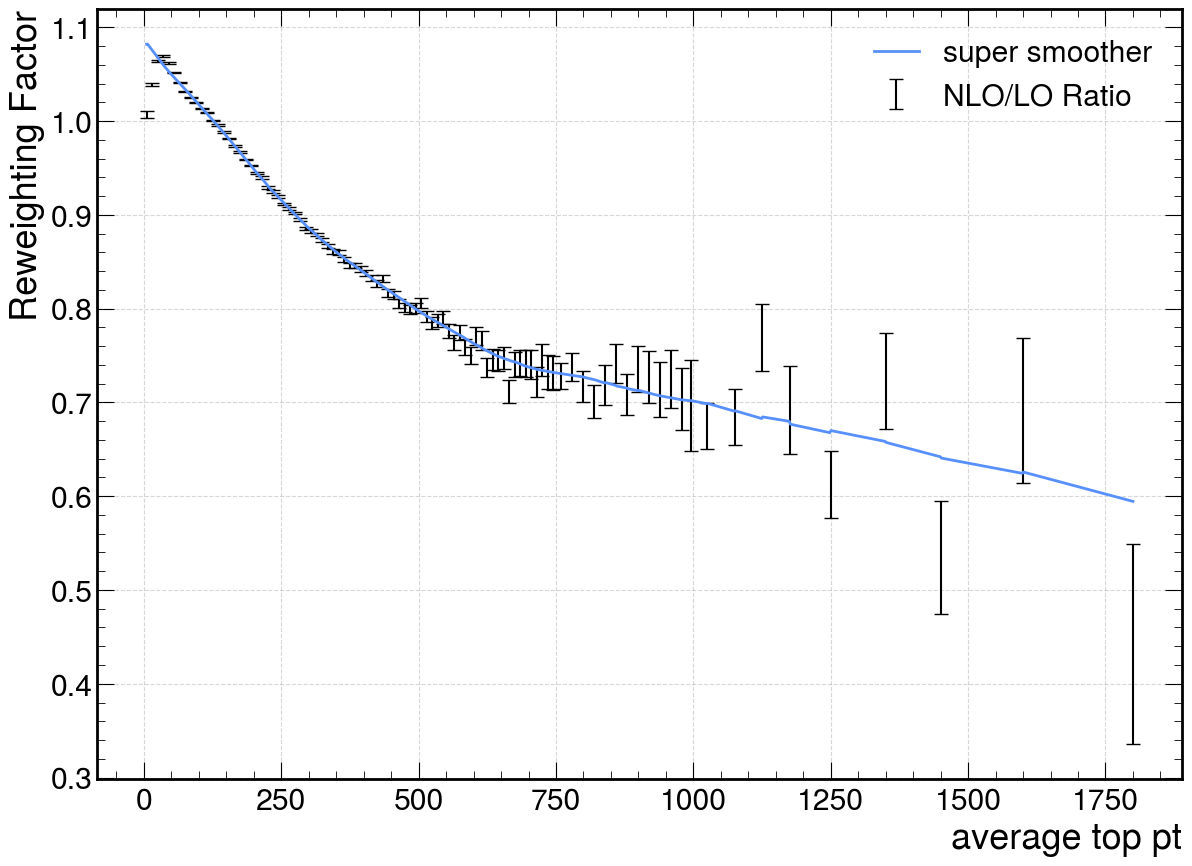

In [79]:
xfine = np.linspace(centers.min(), centers.max(), 1000)
yfit = model.predict(xfine)

hep.style.use('CMS')
fig, ax = plt.subplots(
    figsize=(14,10)
)

ax.errorbar(centers, ratio, xerr = None, yerr = sigma_y, capsize=5, ls='none', color='black', label='NLO/LO Ratio')
ax.plot(xfine, yfit, linewidth=2, label='super smoother')
# ax.plot(xfine, y_exp_poly, linewidth=2, label='exp')
# ax.plot(xfine, y_log_poly, linewidth=1, label='log poly')
# ax.plot(xfine, y_pade22, linewidth=1, label='pade22')
# ax.plot(xfine, y_pade220, linewidth=1, label='pade220')
# ax.plot(xfine, y_pade33, linewidth=1, label='pade33')


ax.set_ylabel("Reweighting Factor")
ax.set_xlabel("average top pt")
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()

(0.3, 2.0)

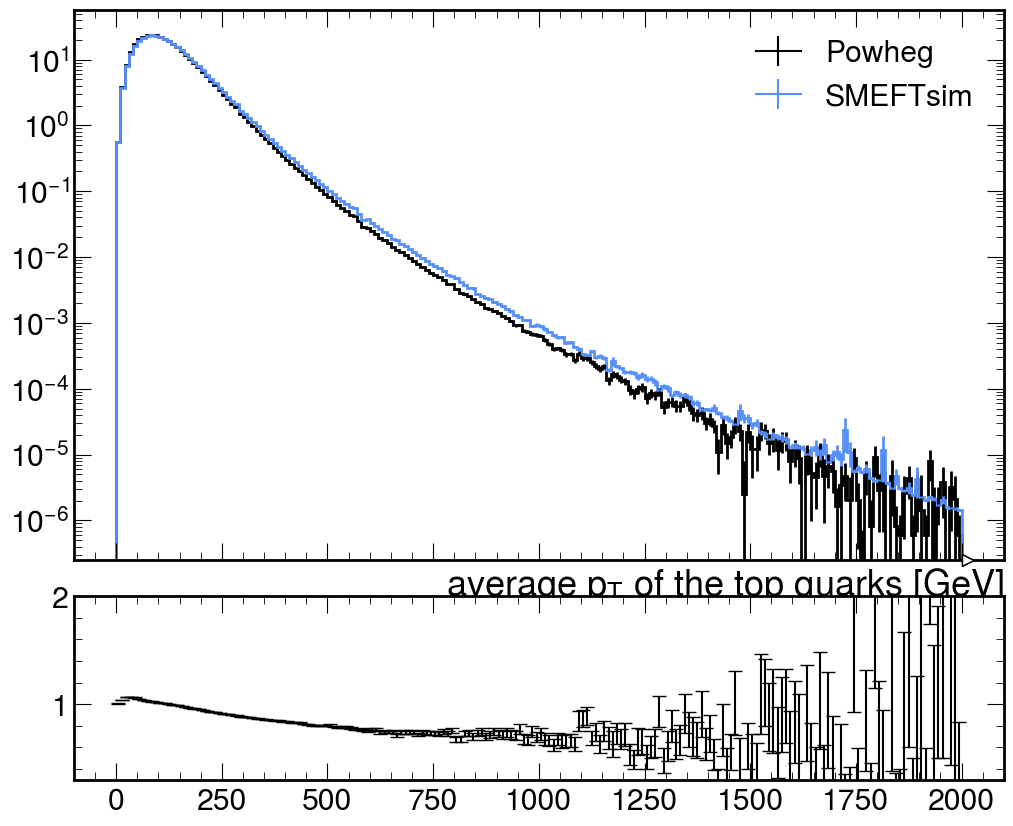

In [127]:
Powheg = pickle.load(gzip.open("Powheg_avgpt_smallerbins.pkl.gz"))['ttbar']['avg_toppt']
SMEFTsim = pickle.load(gzip.open("SMEFTsim_avgpt_smallerbins.pkl.gz"))['ttbar']['avg_toppt']

hep.style.use('CMS')
fig, (ax, rax) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12,10),
    gridspec_kw={'height_ratios': (3, 1)},
    sharex=True
)
fig.subplots_adjust(hspace=.1)

yvals_num = Powheg.values()
yvals_denom = SMEFTsim.values()
ratio = yvals_num/yvals_denom
centers = SMEFTsim.axes.centers[0]
sigma_num = np.sqrt(Powheg.variances())
sigma_denom = np.sqrt(SMEFTsim.variances())
sigma_y = np.multiply(np.abs(ratio), np.sqrt(np.add(np.square(np.divide(sigma_num, yvals_num)), np.square(np.divide(sigma_denom, yvals_denom)))))

# rax.scatter(centers, ratio, label="new")
rax.errorbar(centers, ratio, xerr = None, yerr = sigma_y, capsize=5, ls='none', color='black')

hep.histplot(Powheg, ax=ax, stack=False, yerr=True, linewidth=2, label='Powheg', color='black')
hep.histplot(SMEFTsim, ax=ax, stack=False, yerr=True, linewidth=2, label='SMEFTsim')

ax.legend()
ax.set_yscale('log')
# ax.set_xlim([800, 2000])
rax.set_ylim([0.3, 2])

/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/mplhep/error_estimation.py:49: RuntimeWarning: divide by zero encountered in divide
  counts = sumw / scale


(0.3, 1.5)

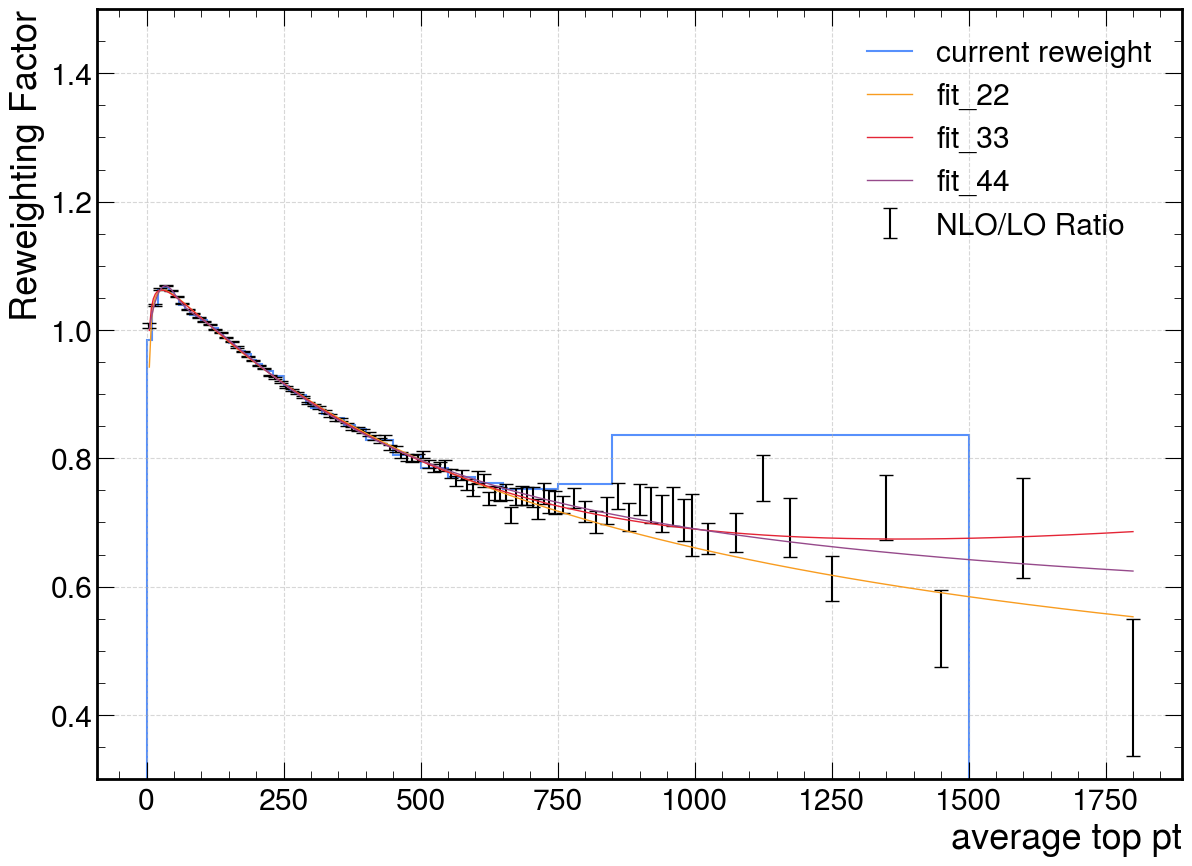

In [147]:
def pade22(x, p0, p1, p2, p3, p4):
    return (p0 + p1*x + p2*x**2) / (1 + p3*x + p4*x**2)

pade22_popt0, pade22_pcov0 = curve_fit(pade_22, centers[1:], ratio[1:], 
                       sigma=sigma_y[1:], p0=[1.0, 0.01, 0.0001, 0.01, 0.0001])

def pade33(x, p0, p1, p2, p3, p4, p5, p6):
    return (p0 + p1*x + p2*x**2 + p5*x**3) / (1 + p3*x + p4*x**2 + p6*x**3)

def pade44(x, n0, n1, n2, n3, n4, d1, d2, d3, d4):
    return (n0 + n1*x + n2*x**2 + n3*x**3 + n4*x**4) / (1 + d1*x + d2*x**2 + d3*x**3 + d4*x**4)

pade33_popt, pade33_pcov = curve_fit(pade33, centers, ratio, 
                       sigma=sigma_y, p0=[1.0, 0.01, 0.0001, 0.01, 0.0001, 0.0001, 0.00001])

pade44_popt, pade44_pcov = curve_fit(pade44, centers, ratio, 
                       sigma=sigma_y, p0=[1.0, 0.01, 0.0001, 0.0001, 0.0001, 0.01, 0.000001, 0.0001, 0.000001])


# [0,    1,    2,     5,    7,      3,      4,      6,         8
# [1.0, 0.01, 0.0001, 0.01, 0.0001, 0.0001, 0.0001, 0.000001, 0.000001]

xfine = np.linspace(centers.min(), centers.max(), 500)
y_fit = pade22(xfine, *pade22_popt0)
y_pade33 = pade33(xfine, *pade33_popt)
y_pade44 = pade44(xfine, *pade44_popt)


hep.style.use('CMS')
fig, ax = plt.subplots(
    figsize=(14,10)
)

ax.errorbar(centers, ratio, xerr = None, yerr = sigma_y, capsize=5, ls='none', color='black', label='NLO/LO Ratio')
hep.histplot(current_reweight, label='current reweight', yerr=False)

# ax.plot(xfine, y_exp_poly, linewidth=2, label='exp')
# ax.plot(xfine, y_log_poly, linewidth=1, label='log poly')
# ax.plot(xfine, y_pade, linewidth=1, label='pade')
ax.plot(xfine, y_fit, linewidth=1, label='fit_22')
ax.plot(xfine, y_pade33, linewidth=1, label='fit_33')
ax.plot(xfine, y_pade44, linewidth=1, label='fit_44')


# ax.plot(xfine, y_pade33, linewidth=1, label='pade33')
# ax.plot(xfine, y_exp_poly, linewidth=1, label='exp_poly')


ax.set_ylabel("Reweighting Factor")
ax.set_xlabel("average top pt")
ax.grid(True, linestyle='--', alpha=0.5)
# ax.set_xlim([0, 500])
ax.legend()
ax.set_ylim([0.3, 1.5])

In [145]:
print(pade22_popt0)

[-4.85486634e+03  6.22773193e+03  2.37352863e+00  5.55459024e+03
  7.46005508e+00]


In [148]:
pade44_popt

array([ 9.73848630e-01,  1.48853423e-04, -3.75993502e-04,  6.43916833e-06,
        1.01454384e-08, -6.48420500e-03, -1.79916355e-04,  4.09463685e-06,
        1.95790951e-08])